# Tech Challenge Fiap - Fase 1

## Case NPS Preditivo
Prever satisfação do cliente (NPS) antes da aplicação da pesquisa

## Fase 2 - Data Understanding

Aqui é onde vamos conhecer os dados, entender a relação dos dados com o problema de negócio e gerar insights acionáveis. 

In [46]:
# Libraries 

import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [47]:
# Loading .csv
# Creating Target variable 

df = pd.read_csv("desafio_nps_fase_1.csv")

df["nps_detrator"] = (df['nps_score'] <= 6).astype(int)


## 1. Reconhecendo a estrutura do codigo

Aqui é onde vamos conhecer os dados, entender a relação dos dados com o problema de negócio e gerar insights acionáveis.  

In [48]:
# Recognizing code structure

#Quantas linhas e colunas tem o Dataset
df.shape

(2500, 20)

Dataset com 2500 linhas e 20 colunas

In [49]:
# Primeiras linhas do Dataset
df.head()

,customer_id,customer_age,customer_region,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_detrator
0,1,63,Nordeste,14,50001,139.73,4,39.35,4,2,2,55.53,3,0,4,6.9,0,3,6.5,0
1,2,20,Sul,1,50002,458.95,2,9.51,10,6,4,28.23,3,0,10,2.4,0,3,0.0,1
2,3,46,Nordeste,111,50003,507.06,5,42.82,6,6,1,40.99,1,4,5,4.8,0,7,1.5,1
3,4,52,Centro-Oeste,117,50004,302.19,2,19.58,9,5,2,35.24,3,1,11,5.9,0,4,0.3,1
4,5,56,Norte,50,50005,253.06,1,29.37,11,13,1,39.32,1,1,0,6.1,0,3,7.9,0


Temos variaveis importantes de logistica, atendimento, pedido e região. 

In [50]:
# Tipo cada variavel
df.dtypes

customer_id                    int64
customer_age                   int64
customer_region                  str
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
nps_detrator                   int64
dtype: object

Sabendo cada tipo de variáveis e que tipo de dado estamos tratando.

- Variáveis numericas  




- Variáveis categóricas  

In [51]:
# Dataset tem algum valor nulo?
df.isnull().sum()

customer_id                  0
customer_age                 0
customer_region              0
customer_tenure_months       0
order_id                     0
order_value                  0
items_quantity               0
discount_value               0
payment_installments         0
delivery_time_days           0
delivery_delay_days          0
freight_value                0
delivery_attempts            0
customer_service_contacts    0
resolution_time_days         0
nps_score                    0
repeat_purchase_30d          0
complaints_count             0
csat_internal_score          0
nps_detrator                 0
dtype: int64

Nesse Dataset não temos dados nulos em nenhuma coluna.

In [52]:
# Existem valores faltantes?
df.duplicated().sum()

np.int64(0)

Tambem não temos dados duplicados nas linhas.

## 2. Estatistica Descritiva

Estatistica Descritiva revela o comportamento central e dispersão de cada variável.

In [53]:
# Descritive Statistics 

# média, mediana, desvio padrão, mín/máx de todas as variaveis numéricas
df.describe()

,customer_id,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,delivery_attempts,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,csat_internal_score,nps_detrator
count,2500.00000,2500.000000,2500.000000,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,43.396000,61.322400,51250.50000,434.259740,3.470800,29.745620,6.004000,8.022000,2.187200,38.217016,2.005600,1.519600,5.485600,4.378600,0.087200,4.150400,2.941600,0.740400
std,721.83216,14.888487,34.478729,721.83216,289.772497,1.687331,29.225603,3.159743,3.770411,1.454442,12.076074,0.815497,1.231512,3.458002,2.510229,0.282184,1.784223,2.378957,0.438503
min,1.00000,18.000000,1.000000,50001.00000,7.760000,1.000000,0.020000,1.000000,2.000000,0.000000,2.620000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,625.75000,31.000000,31.000000,50625.75000,220.245000,2.000000,8.885000,3.000000,5.000000,1.000000,29.927500,1.000000,1.000000,2.000000,2.600000,0.000000,3.000000,0.700000,0.000000
50%,1250.50000,43.000000,62.000000,51250.50000,375.515000,3.000000,20.935000,6.000000,8.000000,2.000000,38.500000,2.000000,1.000000,6.000000,4.400000,0.000000,4.000000,2.800000,1.000000
75%,1875.25000,56.000000,91.000000,51875.25000,577.290000,5.000000,40.832500,9.000000,11.000000,3.000000,46.270000,3.000000,2.000000,8.000000,6.100000,0.000000,5.000000,4.800000,1.000000
max,2500.00000,69.000000,119.000000,52500.00000,1983.810000,6.000000,230.330000,11.000000,14.000000,8.000000,76.130000,3.000000,7.000000,11.000000,10.000000,1.000000,11.000000,10.000000,1.000000


**Com o .describe() conseguimos analisar mais profundamente os dados, vamos avaliar por variavel:**

customer_age: Temos uma média de idade de 43 anos, sendo 50% ou menos dos clientes com essa idade, ou seja, pelo perfil dos clientes estamos trantando de pessoas jovens. 

customer_tenure_months: 61 meses é a média que o cliente esta na base da empresa, podemos dizer que os clientes são fiéis a empresa.

delivery_time_days: Média de 8 dias para a entrega do pedido, sendo 25% dos clientes recebendo entre 9 e 11 dias. 

delivery_delay_days: Média de 2 dias de atraso em algumas entregas, sendo que temos 25% dos clientes com atraso de 3 a 8 dias. 

nps_score: Média do nps de apenas 4.37, ou seja, muito baixo. sendo 75% dos clientes estão avaliando a empresa com nota 6.1 ou menos, a prática representa 75% dos clientes são Detratores. 

## 3. Analisando Target 

Evidenciando desbalanceamento do Dataset. 

In [54]:
# 1. Calculamos a contagem absoluta
contagem = df['nps_detrator'].value_counts()

# 2. Calculamos a porcentagem (normalize=True traz a proporção, multiplicamos por 100)
porcentagem = df['nps_detrator'].value_counts(normalize=True) * 100

# 3. Criamos um novo DataFrame (o "quadro") combinando os dois
quadro_nps = pd.DataFrame({
    'Quantidade': contagem,
    'Porcentagem (%)': porcentagem
})

# Opcional: Formatar a porcentagem para 2 casas decimais
quadro_nps['Porcentagem (%)'] = quadro_nps['Porcentagem (%)'].map('{:.2f}%'.format)

print(quadro_nps)

              Quantidade Porcentagem (%)
nps_detrator                            
1                   1851          74.04%
0                    649          25.96%


Dataset incrivelmente detrator de clientes Detratores, representando 74% da base.

Esse desbalanceamento do Dataset está alinhado com o objetivo análitico 1 e por que Recall deve ser a métrica prioritária. Para a empresa é menos custoso identificar todos os futuros clientes detratores mesmo que tenham falsos positivos (clientes que não seriam ou já satisfeito) do que aumentar o Precision e identificar não todos Detratores. 

Recall alto → o modelo captura a maioria dos Detratores → a empresa consegue agir preventivamente 

Precision alta → o modelo é cauteloso → mas pode deixar Detratores passarem sem ação


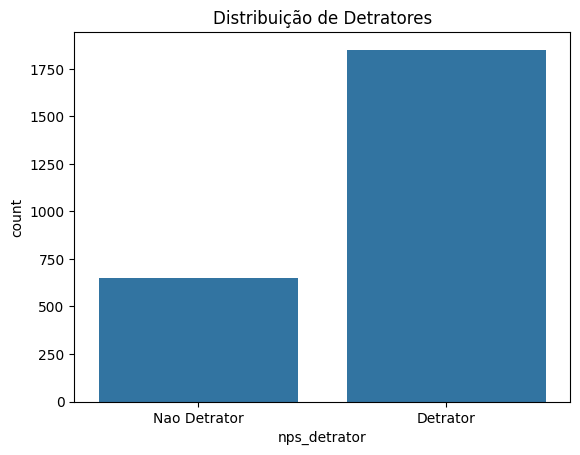

In [55]:
sns.countplot(data=df, x='nps_detrator')

plt.title('Distribuição de Detratores')

plt.xticks([0, 1], ['Nao Detrator', 'Detrator']);

## 4. Distribuicao de Variaveis 

Vamos usar as variaveis abaixo e fazer associacoes com NPS<6.  

**Logística → o cliente recebeu no prazo? Precisou de muitas tentativas de entrega?**  
Logística: delivery_delay_days, delivery_attempts, delivery_time_days    

**Atendimento → o cliente precisou contatar o suporte? O problema foi resolvido rápido?**  
Atendimento: customer_service_contacts, resolution_time_days, complaints_count      

**Pedido → o valor do pedido ou do frete influencia a percepção de satisfação?**    
Pedido: order_value, freight_value  

### Grupo Logistica

Estamos avaliando variaveis logisticas, estamos tentando encontrar comportamento das variaveis como por exemplo: clientes com mais dias de atraso e mais tentativas de entrega tendem a ser Detratores?

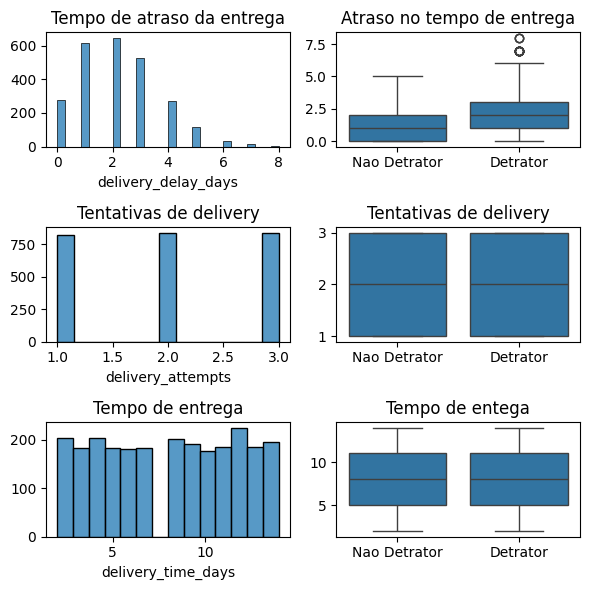

In [56]:

# Grupo Logistica 
fig, axes = plt.subplots(3, 2, figsize=(6, 6))

# Linha 0 - delivery_delay_days
sns.histplot(data=df, x='delivery_delay_days', ax=axes[0, 0])
axes[0,0].set_title("Tempo de atraso da entrega")
axes[0,0].set_ylabel("")

sns.boxplot(data=df, x='nps_detrator', y='delivery_delay_days', ax=axes[0, 1])
axes[0,1].set_title("Atraso no tempo de entrega")
axes[0,1].set_ylabel("")
axes[0,1].set_xlabel("")
axes[0,1].set_xticks([0, 1], ['Nao Detrator', 'Detrator'])

# Linha 1 - delivery_attempts
sns.histplot(data=df, x='delivery_attempts', ax=axes[1, 0])
axes[1,0].set_title("Tentativas de delivery")
axes[1,0].set_ylabel("")

sns.boxplot(data=df, x='nps_detrator', y='delivery_attempts', ax=axes[1, 1])
axes[1,1].set_title("Tentativas de delivery")
axes[1,1].set_ylabel("")
axes[1,1].set_xlabel("")
axes[1,1].set_xticks([0, 1], ['Nao Detrator', 'Detrator'])

# Linha 2 - delivery_time_days
sns.histplot(data=df, x='delivery_time_days', ax=axes[2, 0])
axes[2,0].set_title("Tempo de entrega")
axes[2,0].set_ylabel("")

sns.boxplot(data=df, x='nps_detrator', y='delivery_time_days', ax=axes[2, 1])
axes[2,1].set_title("Tempo de entega")
axes[2,1].set_ylabel("")
axes[2,1].set_xlabel("")
axes[2,1].set_xticks([0, 1], ['Nao Detrator', 'Detrator'])

plt.tight_layout()
plt.ylabel("")
plt.show()


### Associacao de Variaveis grupo Logistica

- delivery_delay_days

A distribuição é assimétrica com cauda à direita, a maioria dos pedidos tem 0 a 3 dias de atraso, mas existem casos extremos chegando a 8 dias. Isso indica que atrasos grandes são raros mas existem.

No boxplot, A mediana dos Detratores é claramente maior que a dos Não Detratores. Há outliers apenas no grupo Detrator (círculos acima da caixa). Clientes que sofreram mais dias de atraso na entrega tendem a ser Detratores. Na pratica um cliente típico Não Detrator esperou 1 dia além do prazo e um cliente típico Detrator esperou 2 dias além do prazo.

Atraso na entrega é um fator associado à insatisfação.


- delivery_attempts

Boxplots iguais, sem associação. 
O número de tentativas de entrega não diferencia Detratores de Não Detratores não parece influenciar a satisfação do cliente.


- delivery_time_days    

Boxplots iguais, sem associação. 
Curioso que nao existem pedidos com exatamente 7 dias no dataset.
O tempo total de entrega não influencia a satisfação. O que importa é o atraso em relação ao prazo prometido, não o tempo absoluto.


**Das 3 variáveis logísticas, apenas delivery_delay_days mostrou associação com o NPS. Isso é um insight importante, o problema não é o tempo total de entrega, mas sim o atraso em relação ao prazo prometido. Reduzir o atraso de 2 para 1 dia pode ser suficiente para evitar que um cliente vire Detrator.**


## Grupo Atendimento

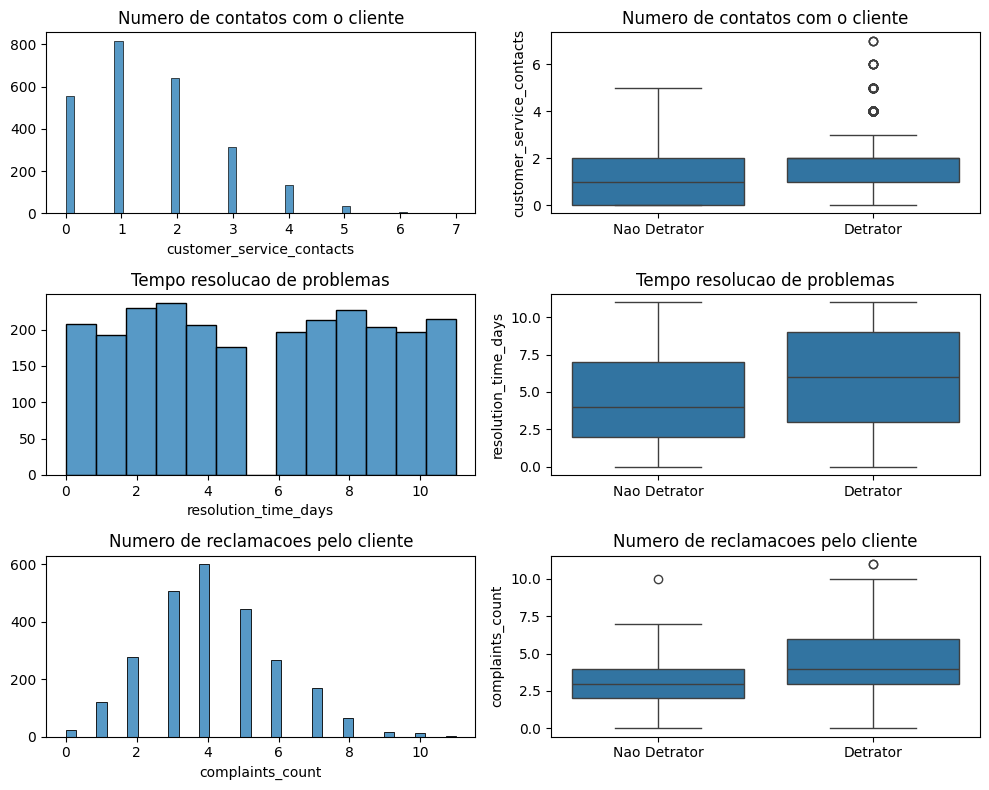

In [57]:
# Grupo Logistica 
fig, axes = plt.subplots(3, 2, figsize=(10, 8))

# Linha 0 - customer_service_contacts
sns.histplot(data=df, x='customer_service_contacts', ax=axes[0, 0])
axes[0,0].set_title("Numero de contatos com o cliente")
axes[0,0].set_ylabel("")

sns.boxplot(data=df, x='nps_detrator', y='customer_service_contacts', ax=axes[0, 1])
axes[0,1].set_title("Numero de contatos com o cliente")
axes[0,1].set_xticks([0, 1], ['Nao Detrator', 'Detrator'])
axes[0,1].set_xlabel("")

# Linha 1 - resolution_time_days
sns.histplot(data=df, x='resolution_time_days', ax=axes[1, 0])
axes[1,0].set_title("Tempo resolucao de problemas")
axes[1,0].set_ylabel("")

sns.boxplot(data=df, x='nps_detrator', y='resolution_time_days', ax=axes[1, 1])
axes[1,1].set_title("Tempo resolucao de problemas")
axes[1,1].set_xticks([0, 1], ['Nao Detrator', 'Detrator'])
axes[1,1].set_xlabel("")

# Linha 2 - complaints_count
sns.histplot(data=df, x='complaints_count', ax=axes[2, 0])
axes[2,0].set_title("Numero de reclamacoes pelo cliente")
axes[2,0].set_ylabel("")

sns.boxplot(data=df, x='nps_detrator', y='complaints_count', ax=axes[2, 1])
axes[2,1].set_title("Numero de reclamacoes pelo cliente")
axes[2,1].set_xticks([0, 1], ['Nao Detrator', 'Detrator'])
axes[2,1].set_xlabel("")

plt.tight_layout()
plt.show()

### Associacao de Variaveis grupo Atendimento

- customer_service_contacts  

No histograma temos uma distribuição assimétrica com cauda a direita, a maioria dos contatos dos clientes com a empresa aconteceram no mesmo dia até 3 dias.
Os boxplots são parecidos mas o grupo Detrator está levemente mais alto.
Clientes que contataram mais vezes o atendimento tendem levemente a ser Detratores, como podemos ver atraves dos outliers. 

- resolution_time_days

A mediana dos Detratores é claramente maior.
Clientes que esperaram mais dias para ter seus problemas resolvidos tendem a ser Detratores. Tempo de resolução é um fator associado à insatisfação.


- complaints_count

No histograma temos uma distribuição simétrica com pico em 4 reclamações por cliente.

No boxplot temos que clientes com maior número de reclamações tendem fortemente a ser Detratores. Essa é a variável de atendimento com sinal mais claro de associação com insatisfação.


**Das 3 variáveis, resolution_time_days e complaints_count mostram associação clara com o NPS baixo. Isso sugere que a qualidade do atendimento é o que impacta a satisfação. Reduzir o tempo de resolução de problemas e reclamações dos clientes poderia ser o suficiente para que um cliente não vire Detrator.**

## Grupo Pedido

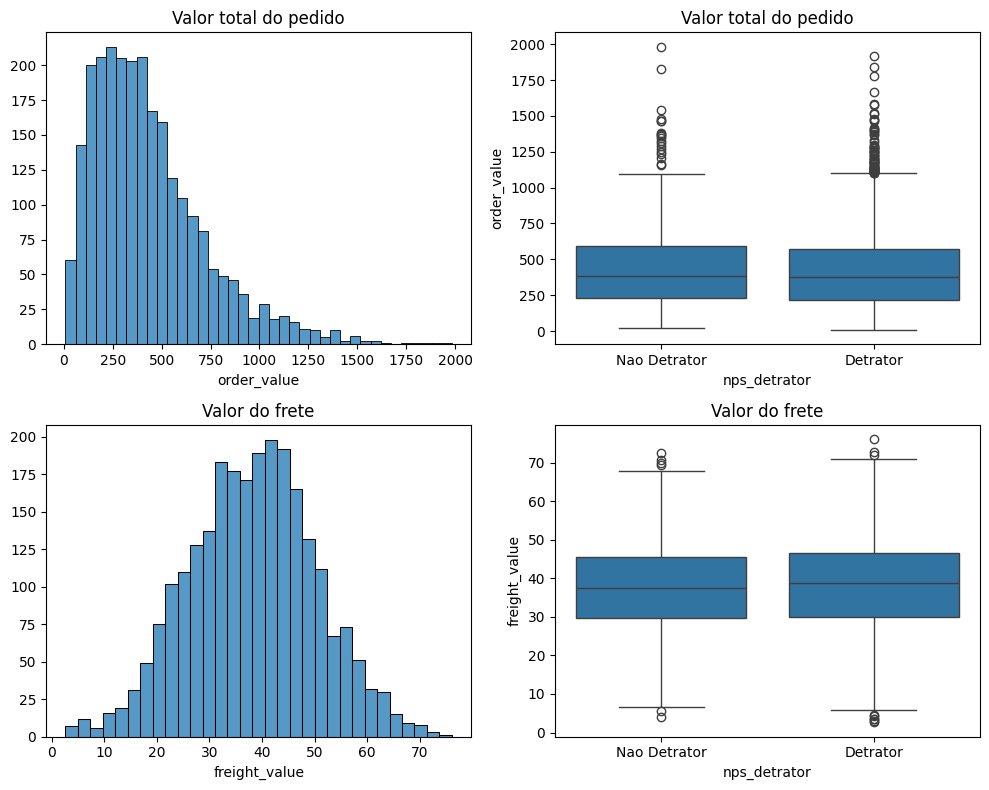

In [58]:
# Grupo Pedido 
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Linha 0 - order_value
sns.histplot(data=df, x='order_value', ax=axes[0, 0])
axes[0,0].set_title("Valor total do pedido")
axes[0,0].set_ylabel("")

sns.boxplot(data=df, x='nps_detrator', y='order_value', ax=axes[0, 1])
axes[0,1].set_title("Valor total do pedido")
axes[0,1].set_xticks([0, 1], ['Nao Detrator', 'Detrator'])

# Linha 1 - resolution_time_days
sns.histplot(data=df, x='freight_value', ax=axes[1, 0])
axes[1,0].set_title("Valor do frete")
axes[1,0].set_ylabel("")

sns.boxplot(data=df, x='nps_detrator', y='freight_value', ax=axes[1, 1])
axes[1,1].set_title("Valor do frete")
axes[1,1].set_xticks([0, 1], ['Nao Detrator', 'Detrator'])

plt.tight_layout()
plt.show()

### Associacao de Variaveis grupo Pedido

Nem o valor do pedido nem o valor do frete parecem influenciar a satisfação do cliente. A insatisfação não está relacionada ao quanto o cliente gastou, mas sim à qualidade da experiência como entrega e atendimento.

## Correlação entre variaveis (HeatMap)

HeatMap mostra quais variaveis tem maior correlação e quais variáveis tem correlação inversamente proporcional, por exemplo tempo de atraso da entrega e contato do cliente com a empresa estão inversamente correlacionadas, quanto maior essas variáveis menor tende a ser o nps score.

As variáveis csat_internal_score e repeat_purchase_30d foram removidas por risco de leakage. 

Lembrando que estamos analisando nossa variavel Target (nps_detrator) e não nps_score.

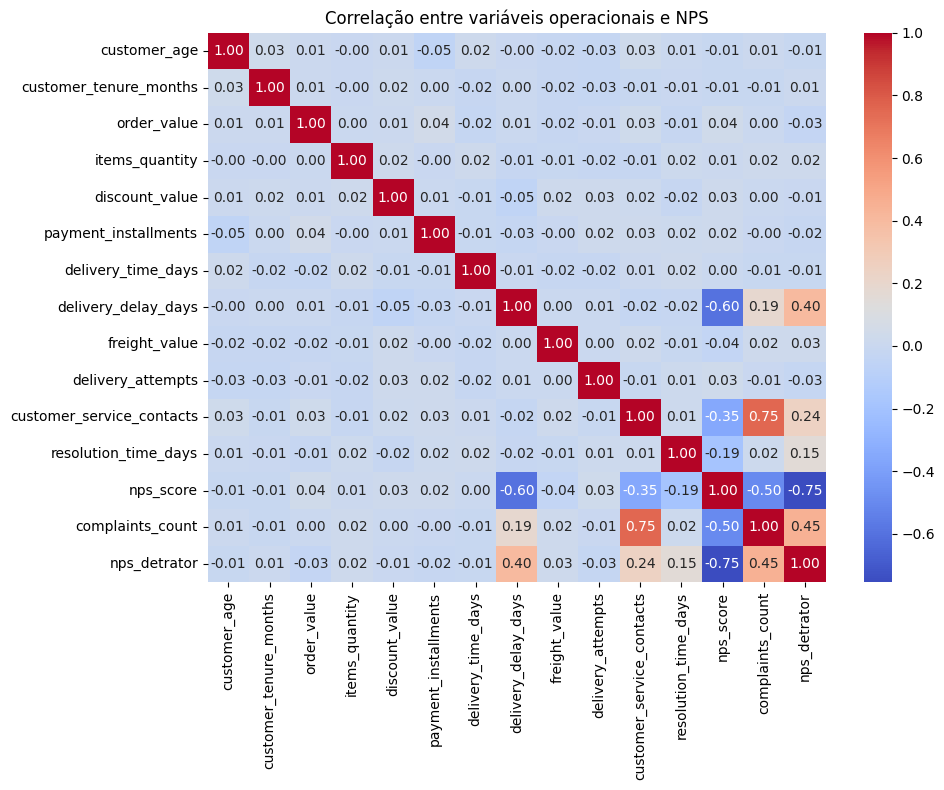

In [59]:
colunas_remover = ['customer_id', 'order_id', 'csat_internal_score', 'repeat_purchase_30d']

correlacao = df.drop(columns=colunas_remover).corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação entre variáveis operacionais e NPS')
plt.tight_layout()
plt.show()

## 5. Interpretação do Heatmap

### Variaveis relevantes
As variáveis com maior correlação com nps_detrator são complaints_count (0.45) e delivery_delay_days (0.40), confirmando os achados visuais dos boxplots. Clientes com mais reclamações e mais dias de atraso tendem a ser Detratores.

### Variaveis fracas
customer_service_contacts (0.24) e resolution_time_days (0.15) apresentam correlação fraca com o target.

### Variaveis inversamente correlacionais
nps_score (-0.75) apresenta correlação negativa, enquanto nps_score sobe, nps_detrator cai.  

nps_detrator = 1 quando nps_score ≤ 6 → nota baixa = Detrator  
nps_detrator = 0 quando nps_score > 6 → nota alta = Não Detrator  

### Conclusão de negócio
Esses resultados sugerem que a empresa deve priorizar a redução de reclamações e o cumprimento de prazos de entrega como principais alavancas para melhorar a satisfação do cliente.

Com isso, o Objetivo Analítico 1 foi respondido, as top 3 variáveis associadas ao NPS ≤ 6 são:  
- complaints_count
- delivery_delay_days
- resolution_time_days

## 6. Análise por Região 

Verificando se a taxa de Detratores varia entre as regiões do Brasil, isso conecta diretamente ao risco de viés regional do objetivo Analítico 1 — Análise Diagnóstica.

In [60]:
df.groupby('customer_region')['nps_detrator'].mean()

customer_region
Centro-Oeste    0.743590
Nordeste        0.740206
Norte           0.745059
Sudeste         0.746154
Sul             0.727447
Name: nps_detrator, dtype: float64

A diferença entre o maior Detrator, Sudeste (74,6%) e menor Detrator, Sul (72,7%) é de apenas 1,9 ponto percentual.  

**O que isso significa para o negócio?**  
Não parece ter risco de viés regional, todas as regiões estão proximas percentualmente falando.

## 7. Registro Final dos Insights

A análise exploratória identificou que as variáveis com maior associação com a insatisfação do cliente foram:

### Atendimento
- complaints_count (0.45)

### Logistico
- delivery_delay_days (0.40)



Variaveis customer_service_contacts (0.24) e resolution_time_days (0.15) apresentam correlação fraca com o target e a variavel delivery_attempts (-0.03) não apresenta correlação relevante com a satisfação do cliente.  

A análise regional mostrou que não há viés regional.

Portanto temos que focar no lado do atendimento as reclamações dos clientes e resolve-las o mais rápido possiível e do lado da logística, o menos de atraso possivel. 


Como próximos passos, na fase de Data Preparation serão removidas as variáveis sem relevância e as proibidas por leakage (csat_internal_score, repeat_purchase_30d). As variáveis complaints_count e delivery_delay_days serão priorizadas como features do modelo preditivo.